# Modelo Prescriptivo para Optimización de Inventario: Sistema (s, Q)

## 1. Objetivo
El objetivo de este notebook es desarrollar un modelo prescriptivo para optimizar la política de inventario de un retail utilizando un **Sistema de Revisión Continua (s, Q)**. Se calcularán los valores óptimos para:

- **Q (Cantidad de Pedido):** La cantidad óptima a pedir para minimizar los costos de orden y mantenimiento.
- **s (Punto de Reorden):** El nivel de inventario en el cual se debe emitir una nueva orden de pedido.

El modelo generará recomendaciones de compra basadas en el inventario actual y los parámetros óptimos calculados, considerando diferentes escenarios de costos logísticos.

## 2. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm 

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3. Carga de Dato
Se cargarán los siguientes archivos, que son la base de nuestro análisis:
- **productos.csv:** Catálogo de productos y sus características (costo, proveedor, lead time, etc.).
- **ventas.csv:** Historial de ventas del año 2023.
- **inventario.csv:** Stock disponible al 15 de enero de 2024.
- **Costos_Logisticos.csv:** Escenarios con diferentes costos de operación.

In [2]:
try:
    df_productos = pd.read_csv('productos.csv')
    df_ventas = pd.read_csv('ventas.csv')
    df_inventario = pd.read_csv('inventario.csv')
    df_costos = pd.read_csv('Costos_Logisticos.csv')

    print("Datos cargados exitosamente.")
    print(f"Productos: {df_productos.shape[0]} filas")
    print(f"Ventas: {df_ventas.shape[0]} filas")
    print(f"Inventario: {df_inventario.shape[0]} filas")
    print(f"Escenarios de Costos: {df_costos.shape[0]} filas")
except FileNotFoundError as e:
    print(f"Error al cargar los archivos: {e}. Asegúrate de que los archivos CSV estén en el mismo directorio que el notebook.")

Datos cargados exitosamente.
Productos: 100 filas
Ventas: 940550 filas
Inventario: 600 filas
Escenarios de Costos: 5 filas


### 3.1. Vistazo Rápido a los Datos

In [3]:
print("--- Muestra de Productos ---")
display(df_productos.head(3))
print("\n--- Muestra de Ventas ---")
display(df_ventas.head(3))
print("\n--- Muestra de Inventario ---")
display(df_inventario.head(3))
print("\n--- Muestra de Costos Logísticos ---")
display(df_costos.head(3))

--- Muestra de Productos ---


,sku,categoria,subcategoria,talla,color,costo_unitario,precio_venta,proveedor_id,lead_time_dias,cantidad_minima_pedido,multiplico_pedido,temporada,margen
0,HM000001,Vestidos,Temporada,XL,Negro,10.35,17.75,PROV001,18,50,10,Invierno,7.40
1,HM000002,Camisetas,Temporada,L,Rojo,34.60,40.98,PROV002,12,50,10,Verano,6.38
2,HM000003,Abrigos,Basico,L,Blanco,40.50,68.38,PROV003,12,100,25,Verano,27.88



--- Muestra de Ventas ---


,fecha,tienda,sku,cantidad_vendida,precio_venta_unitario,descuento_aplicado,venta_neta
0,2023-01-01,TIENDA001,HM000088,1,28.24,0.2,22.592
1,2023-01-01,TIENDA001,HM000096,1,64.60,0.1,58.140
2,2023-01-01,TIENDA001,HM000100,2,28.23,0.2,45.168



--- Muestra de Inventario ---


,tienda,sku,stock_actual,stock_seguridad_actual,stock_en_transito,fecha_ultima_reposicion
0,TIENDA001,HM000084,18,16,16,2024-01-06
1,TIENDA001,HM000054,54,23,20,2023-12-30
2,TIENDA001,HM000071,62,17,26,2024-01-03



--- Muestra de Costos Logísticos ---


,Escenario,costo_pedido,costo_mantenimiento_anual,costo_almacenamiento_m2,costo_transferencia_tienda,costo_rotura_stock,costo_obsolescencia
0,Escenario 1,10.0,0.15,80.0,3.0,0.20,0.09
1,Escenario 2,40.0,0.20,100.0,4.0,0.25,0.12
2,Escenario 3,50.0,0.25,120.0,5.0,0.30,0.15


## 4. Preprocesamiento y Análisis de Demanda

Para calcular los parámetros del modelo (s, Q), primero necesitamos entender la demanda de cada producto. Esto implica:

1.  **Limpiar y filtrar** los datos de ventas para el período de análisis (2023).
2.  **Calcular la demanda diaria** para cada combinación `sku`-`tienda`.
3.  **Estimar la demanda promedio diaria (d)** y su **desviación estándar (σd)**, métricas clave para determinar el stock de seguridad.

In [4]:
# Convertir la columna 'fecha' a formato datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

# Filtrar ventas para el año 2023
df_ventas_2023 = df_ventas[df_ventas['fecha'].dt.year == 2023].copy()

print(f"Rango de fechas en los datos de ventas: {df_ventas_2023['fecha'].min().date()} a {df_ventas_2023['fecha'].max().date()}")

Rango de fechas en los datos de ventas: 2023-01-01 a 2023-12-31


In [5]:
# Agrupar ventas por día, tienda y sku para obtener la demanda diaria
demanda_diaria = df_ventas_2023.groupby(['fecha', 'tienda', 'sku'])['cantidad_vendida'].sum().reset_index()
demanda_diaria.rename(columns={'cantidad_vendida': 'demanda'}, inplace=True)

# Crear un rango de fechas completo para 2023
fechas_2023 = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Crear un MultiIndex con todas las combinaciones posibles de tienda, sku y fecha
tiendas = demanda_diaria['tienda'].unique()
skus = demanda_diaria['sku'].unique()
multi_index = pd.MultiIndex.from_product([fechas_2023, tiendas, skus], names=['fecha', 'tienda', 'sku'])

# Crear un DataFrame completo y rellenar la demanda faltante con 0
demanda_completa = demanda_diaria.set_index(['fecha', 'tienda', 'sku']).reindex(multi_index, fill_value=0).reset_index()

print("DataFrame con demanda diaria completa (días sin ventas rellenos con 0):")
display(demanda_completa.sample(5))

DataFrame con demanda diaria completa (días sin ventas rellenos con 0):


,fecha,tienda,sku,demanda
274265,2023-10-02,TIENDA003,HM000067,1
266293,2023-09-24,TIENDA003,HM000097,1
275314,2023-10-03,TIENDA004,HM000015,7
141547,2023-05-22,TIENDA006,HM000049,5
195135,2023-07-15,TIENDA002,HM000037,11


In [6]:
# Calcular la demanda promedio diaria (d) y la desviación estándar de la demanda (std_demanda)
stats_demanda = demanda_completa.groupby(['tienda', 'sku'])['demanda'].agg(['mean', 'std']).reset_index()
stats_demanda.rename(columns={'mean': 'demanda_promedio_diaria', 'std': 'std_demanda_diaria'}, inplace=True)

# Rellenar NaN en std_demanda_diaria con 0 (para casos con una sola transacción)
stats_demanda['std_demanda_diaria'] = stats_demanda['std_demanda_diaria'].fillna(0)

print("Estadísticas de demanda calculadas (promedio y desviación estándar):")
display(stats_demanda.head())

Estadísticas de demanda calculadas (promedio y desviación estándar):


,tienda,sku,demanda_promedio_diaria,std_demanda_diaria
0,TIENDA001,HM000001,4.430137,4.140881
1,TIENDA001,HM000002,3.769863,3.207421
2,TIENDA001,HM000003,4.635616,4.482732
3,TIENDA001,HM000004,4.010959,3.359404
4,TIENDA001,HM000005,4.575342,4.369342


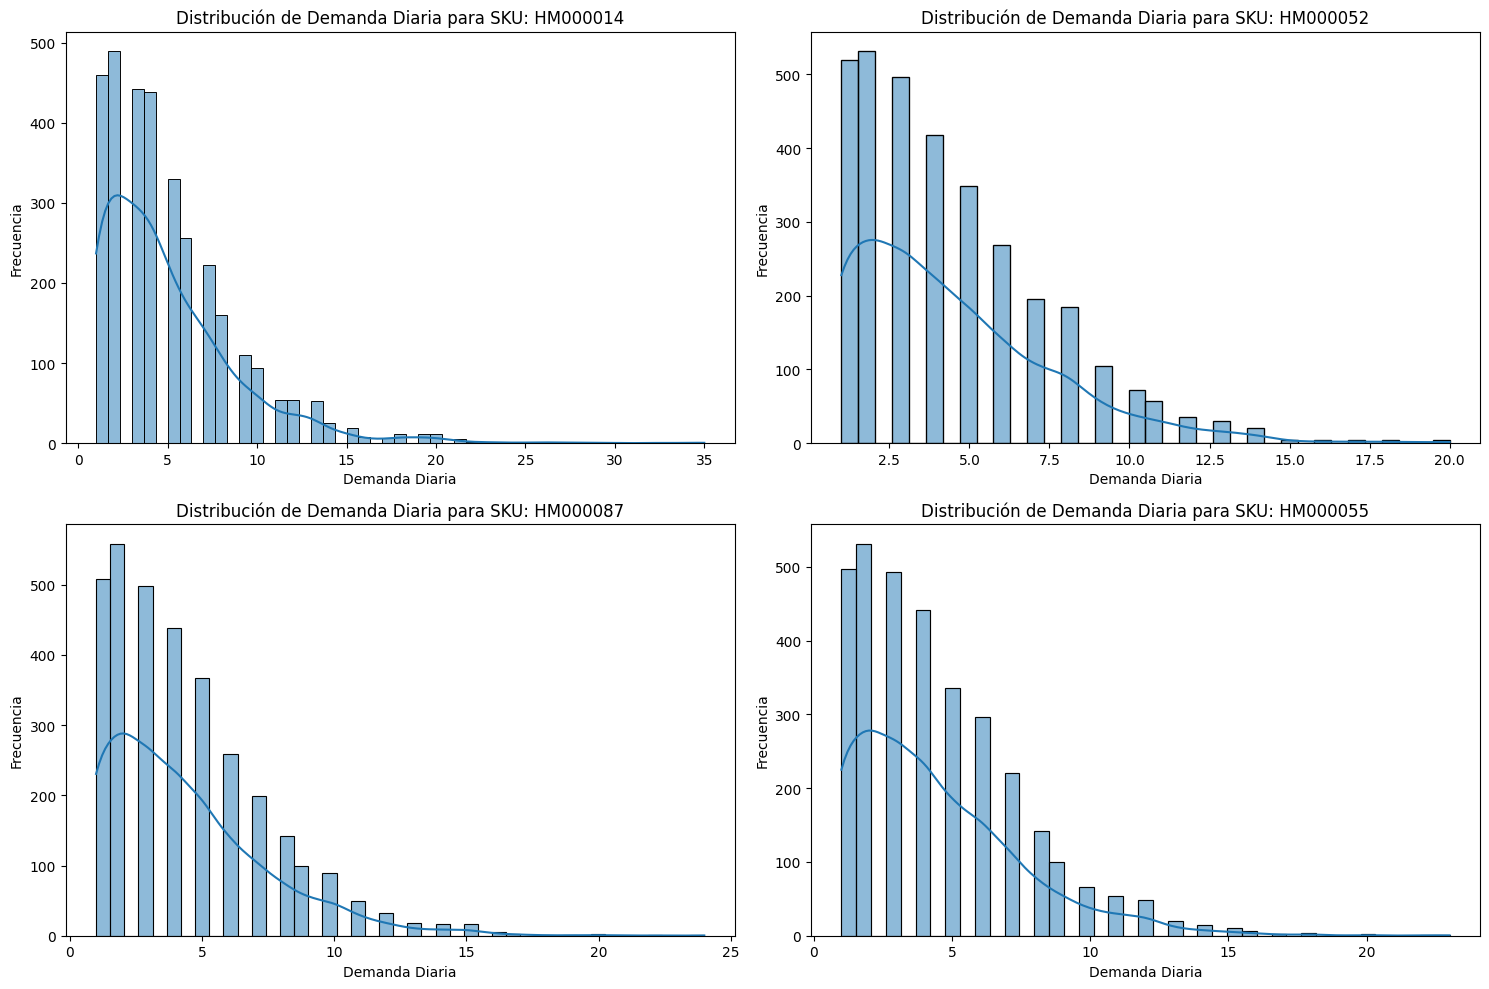

In [7]:
# Visualización de la Distribución de la Demanda
top_skus = df_ventas_2023['sku'].value_counts().nlargest(4).index

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, sku in enumerate(top_skus):
    sku_demand = demanda_completa[(demanda_completa['sku'] == sku) & (demanda_completa['demanda'] > 0)]['demanda']
    sns.histplot(sku_demand, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de Demanda Diaria para SKU: {sku}')
    axes[i].set_xlabel('Demanda Diaria')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 4.1. Consolidación de Datos

Ahora, unimos toda la información en un único DataFrame maestro. Esto facilitará los cálculos posteriores al tener todos los datos necesarios en una sola tabla:

- Estadísticas de demanda (`stats_demanda`)
- Información de producto (`df_productos`)
- Datos de inventario actual (`df_inventario`)

In [8]:
# Unir estadísticas de demanda con la información de productos
df_master = pd.merge(stats_demanda, df_productos, on='sku', how='left')

# Unir el resultado con los datos de inventario
df_master = pd.merge(df_master, df_inventario, on=['tienda', 'sku'], how='left')

# Rellenar con 0 el stock para productos que están en nuestro catálogo pero no tienen registro de inventario
df_master['stock_actual'] = df_master['stock_actual'].fillna(0)
df_master['stock_seguridad_actual'] = df_master['stock_seguridad_actual'].fillna(0)
df_master['stock_en_transito'] = df_master['stock_en_transito'].fillna(0)

# Seleccionar y renombrar columnas para mayor claridad
df_master = df_master[[
    'tienda', 'sku', 'categoria', 'subcategoria', 'costo_unitario', 'precio_venta', 
    'lead_time_dias', 'cantidad_minima_pedido', 'multiplico_pedido',
    'demanda_promedio_diaria', 'std_demanda_diaria', 'stock_actual', 'stock_en_transito'
]].copy()

print("DataFrame Maestro consolidado:")
display(df_master.head())

DataFrame Maestro consolidado:


,tienda,sku,categoria,subcategoria,costo_unitario,precio_venta,lead_time_dias,cantidad_minima_pedido,multiplico_pedido,demanda_promedio_diaria,std_demanda_diaria,stock_actual,stock_en_transito
0,TIENDA001,HM000001,Vestidos,Temporada,10.35,17.75,18,50,10,4.430137,4.140881,68.0,22.0
1,TIENDA001,HM000002,Camisetas,Temporada,34.60,40.98,12,50,10,3.769863,3.207421,86.0,30.0
2,TIENDA001,HM000003,Abrigos,Basico,40.50,68.38,12,100,25,4.635616,4.482732,87.0,22.0
3,TIENDA001,HM000004,Camisetas,Temporada,37.49,19.15,8,100,50,4.010959,3.359404,34.0,47.0
4,TIENDA001,HM000005,Accesorios,Temporada,35.92,56.41,15,50,25,4.575342,4.369342,57.0,39.0


## 5. Implementación del Modelo (s, Q)

A continuación, se implementa la lógica para calcular los parámetros óptimos del sistema de revisión continua.

### Fórmulas Clave

1.  **Cantidad Óptima de Pedido (Q)** - *Modelo EOQ (Economic Order Quantity)*:
    $$ Q = \sqrt{\frac{2 \cdot D \cdot K}{H}} $$
    Donde:
    - **D:** Demanda anual (`demanda_promedio_diaria * 365`).
    - **K:** Costo por realizar un pedido (`costo_pedido`).
    - **H:** Costo de mantener una unidad en inventario por un año (`costo_unitario * costo_mantenimiento_anual`).

2.  **Punto de Reorden (s)**:
    $$ s = (d \cdot L) + SS $$
    Donde:
    - **d:** Demanda promedio diaria.
    - **L:** Tiempo de entrega del proveedor en días (`lead_time_dias`).
    - **SS:** Stock de Seguridad.

3.  **Stock de Seguridad (SS)**:
    $$ SS = Z \cdot \sigma_{L} $$
    Donde:
    - **Z:** Nivel de servicio deseado (puntuación Z). **Asumiremos un nivel de servicio del 95% (Z = 1.65)**.
    - **σL:** Desviación estándar de la demanda durante el tiempo de entrega, calculado como `std_demanda_diaria * sqrt(L)`.

In [9]:
class OptimizadorInventario:
    def __init__(self, df_master, escenario_costos, nivel_servicio_z=1.65):
        self.df = df_master.copy()
        self.escenario = escenario_costos
        self.z = nivel_servicio_z
        print(f"Optimizador inicializado para '{self.escenario['Escenario']}' con Z={self.z}")

    def _ajustar_q(self, q, moq, multiplo):
        """Ajusta la cantidad de pedido (Q) a las restricciones del proveedor."""
        if q < moq:
            q = moq

        if multiplo > 0:
            q = np.ceil(q / multiplo) * multiplo

        return q

    def calcular_parametros_optimos(self):
        """Calcula Q y s para todos los productos del DataFrame."""
        # Extraer costos del escenario
        K = self.escenario['costo_pedido']
        costo_mantenimiento_anual_pct = self.escenario['costo_mantenimiento_anual']

        # Calcular Demanda Anual (D) y Costo de Mantenimiento (H)
        self.df['demanda_anual'] = self.df['demanda_promedio_diaria'] * 365
        self.df['costo_mantenimiento_unidad'] = self.df['costo_unitario'] * costo_mantenimiento_anual_pct

        # Calcular Q (EOQ) sin ajustar
        # Se añade un valor pequeño (epsilon) para evitar división por cero en H
        epsilon = 1e-6
        self.df['Q_calculado'] = np.sqrt(
            (2 * self.df['demanda_anual'] * K) / (self.df['costo_mantenimiento_unidad'] + epsilon)
        )

        # Ajustar Q a las restricciones de MOQ y múltiplo
        self.df['Q_optimo'] = self.df.apply(
            lambda row: self._ajustar_q(row['Q_calculado'], row['cantidad_minima_pedido'], row['multiplico_pedido']),
            axis=1
        )

        # Calcular Stock de Seguridad (SS) y Punto de Reorden (s)
        self.df['std_demanda_lead_time'] = self.df['std_demanda_diaria'] * np.sqrt(self.df['lead_time_dias'])
        self.df['stock_seguridad'] = self.z * self.df['std_demanda_lead_time']
        self.df['punto_reorden'] = (self.df['demanda_promedio_diaria'] * self.df['lead_time_dias']) + self.df[
            'stock_seguridad']

        # Redondear los resultados a enteros
        self.df['Q_optimo'] = self.df['Q_optimo'].round().astype(int)
        self.df['punto_reorden'] = self.df['punto_reorden'].round().astype(int)
        self.df['stock_seguridad'] = self.df['stock_seguridad'].round().astype(int)

        return self.df

    def z_score_to_service_level(self, z_score):
        """Convierte un Z-score a un nivel de servicio (probabilidad)."""
        return norm.cdf(z_score)

    def calcular_costos_totales(self):
        """Calcula los costos totales anuales para cada producto."""
        # Costo de pedido anual
        self.df['costo_pedido_anual'] = (self.df['demanda_anual'] / self.df['Q_optimo']) * self.escenario['costo_pedido']

        # Costo de mantenimiento anual (considerando Q/2 + stock de seguridad)
        self.df['costo_mantenimiento_anual'] = ((self.df['Q_optimo'] / 2) + self.df['stock_seguridad']) * self.df[
            'costo_mantenimiento_unidad']

        # Costo de rotura de stock (simplificado, asumiendo un porcentaje de la demanda no satisfecha)
        # Esto es una simplificación, en la realidad se modela con la probabilidad de rotura
        self.df['costo_rotura_stock_anual'] = self.df['demanda_anual'] * self.escenario['costo_rotura_stock'] * (1 - self
        .z_score_to_service_level(self.z)) # Asumiendo que (1-SL) es la probabilidad de rotura

        # Costo de obsolescencia (simplificado, un porcentaje del costo unitario del stock de seguridad)
        self.df['costo_obsolescencia_anual'] = self.df['stock_seguridad'] * self.df['costo_unitario'] * self.escenario[
            'costo_obsolescencia']

        # Costo total anual
        self.df['costo_total_anual'] = self.df['costo_pedido_anual'] + self.df['costo_mantenimiento_anual'] + \
                                       self.df['costo_rotura_stock_anual'] + self.df['costo_obsolescencia_anual']
        return self.df

    def generar_recomendaciones(self):
        """Genera recomendaciones de pedido basadas en el inventario actual."""
        # El inventario de posición es el stock actual más lo que está en tránsito
        self.df['inventario_posicion'] = self.df['stock_actual'] + self.df['stock_en_transito']

        # La recomendación se activa si el inventario de posición está por debajo del punto de reorden
        self.df['recomendacion_pedir'] = self.df['inventario_posicion'] <= self.df['punto_reorden']

        # La cantidad a pedir es el Q óptimo
        self.df['cantidad_a_pedir'] = self.df.apply(
            lambda row: row['Q_optimo'] if row['recomendacion_pedir'] else 0,
            axis=1
        )

        recomendaciones = self.df[
            self.df['recomendacion_pedir'] == True
        ][[
            'tienda', 'sku', 'inventario_posicion', 'punto_reorden', 'Q_optimo', 'cantidad_a_pedir'
        ]].sort_values(by='tienda')

        return recomendaciones


## 6. Aplicación del Modelo y Análisis de Escenarios\n
\n
Ahora, aplicaremos el optimizador a cada uno de los escenarios de costos definidos en `Costos_Logisticos.csv`.

In [10]:
resultados_por_escenario = {}

for index, escenario_row in df_costos.iterrows():
    escenario_dict = escenario_row.to_dict()
    nombre_escenario = escenario_dict['Escenario']

    # Crear y ejecutar el optimizador para el escenario actual
    optimizador = OptimizadorInventario(df_master, escenario_dict)
    df_resultado = optimizador.calcular_parametros_optimos()
    df_resultado = optimizador.calcular_costos_totales()  # AÑADIDA ESTA LÍNEA PARA CALCULAR LOS COSTOS

    # Guardar el resultado
    resultados_por_escenario[nombre_escenario] = df_resultado

    print(f"Cálculos completados para {nombre_escenario}.\n")

# Mostramos un ejemplo de los resultados para el 'Escenario 1'
print("\n--- Resultados para Escenario 1 ---")
display(resultados_por_escenario['Escenario 1'][['tienda', 'sku', 'demanda_promedio_diaria', 'Q_optimo', 'stock_seguridad',
                                                'punto_reorden', 'costo_total_anual']].head())  # Se añadió 'costo_total_anual' para la visualización


Optimizador inicializado para 'Escenario 1' con Z=1.65
Cálculos completados para Escenario 1.

Optimizador inicializado para 'Escenario 2' con Z=1.65
Cálculos completados para Escenario 2.

Optimizador inicializado para 'Escenario 3' con Z=1.65
Cálculos completados para Escenario 3.

Optimizador inicializado para 'Escenario 4' con Z=1.65
Cálculos completados para Escenario 4.

Optimizador inicializado para 'Escenario 5' con Z=1.65
Cálculos completados para Escenario 5.


--- Resultados para Escenario 1 ---


,tienda,sku,demanda_promedio_diaria,Q_optimo,stock_seguridad,punto_reorden,costo_total_anual
0,TIENDA001,HM000001,4.430137,150,29,109,312.272573
1,TIENDA001,HM000002,3.769863,80,18,64,542.686548
2,TIENDA001,HM000003,4.635616,100,26,81,742.411145
3,TIENDA001,HM000004,4.010959,100,16,48,586.021846
4,TIENDA001,HM000005,4.575342,100,28,97,694.305870


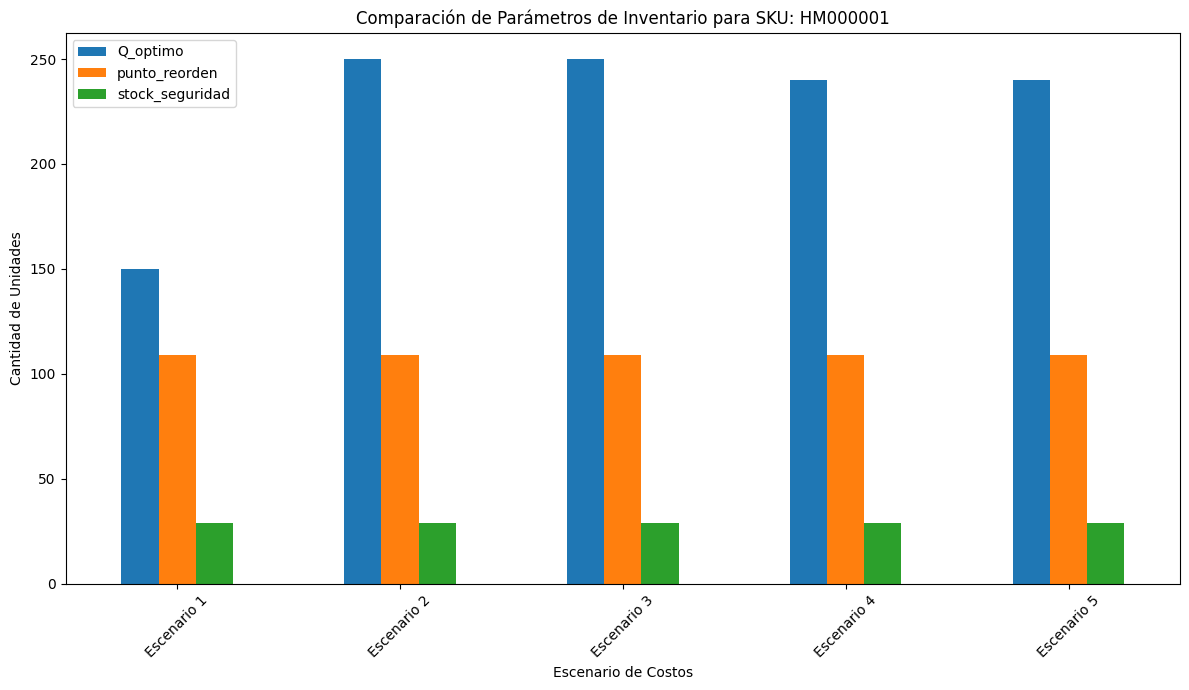

In [11]:
# Comparación de Parámetros entre Escenarios para un SKU de ejemplo
sku_ejemplo = resultados_por_escenario['Escenario 1']['sku'].iloc[0]
datos_comparacion = []

for nombre_escenario, df_resultado in resultados_por_escenario.items():
    # Asumimos una sola tienda para simplificar, o filtramos por una tienda específica
    datos_sku = df_resultado[(df_resultado['sku'] == sku_ejemplo) & (df_resultado['tienda'] == 'TIENDA001')].iloc[0]
    datos_comparacion.append({
        'Escenario': nombre_escenario,
        'Q_optimo': datos_sku['Q_optimo'],
        'punto_reorden': datos_sku['punto_reorden'],
        'stock_seguridad': datos_sku['stock_seguridad']
    })

df_comparacion = pd.DataFrame(datos_comparacion)

fig, ax = plt.subplots(figsize=(12, 7))
df_comparacion.plot(x='Escenario', y=['Q_optimo', 'punto_reorden', 'stock_seguridad'], kind='bar', ax=ax)
ax.set_title(f'Comparación de Parámetros de Inventario para SKU: {sku_ejemplo}')
ax.set_ylabel('Cantidad de Unidades')
ax.set_xlabel('Escenario de Costos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Recomendaciones Prescriptivas Finales\n
\n
Finalmente, generamos la lista de órdenes de compra sugeridas. Para este ejemplo, utilizaremos el **'Escenario 1'** como base para las recomendaciones. Este listado es el resultado prescriptivo principal del análisis, indicando qué comprar, cuánto y para qué tienda.

In [12]:
# Seleccionar el escenario para las recomendaciones finales
escenario_final = 'Escenario 1'
df_resultado_final = resultados_por_escenario[escenario_final]

# Instanciar el optimizador con los datos finales de ese escenario
optimizador_final = OptimizadorInventario(df_resultado_final, df_costos[df_costos['Escenario'] == escenario_final].iloc[0].to_dict())

# Generar la lista de recomendaciones de compra
recomendaciones_compra = optimizador_final.generar_recomendaciones()

print(f"\n--- Lista de Órdenes de Compra Sugeridas para {escenario_final} ---")
if recomendaciones_compra.empty:
    print("No se requieren nuevas órdenes de compra en este momento.")
else:
    display(recomendaciones_compra)

Optimizador inicializado para 'Escenario 1' con Z=1.65

--- Lista de Órdenes de Compra Sugeridas para Escenario 1 ---


,tienda,sku,inventario_posicion,punto_reorden,Q_optimo,cantidad_a_pedir
0,TIENDA001,HM000001,90.0,109,150,150
55,TIENDA001,HM000056,90.0,111,75,75
56,TIENDA001,HM000057,61.0,130,100,100
59,TIENDA001,HM000060,85.0,98,100,100
60,TIENDA001,HM000061,40.0,70,110,110
...,...,...,...,...,...,...
927,TIENDA010,HM000028,0.0,41,100,100
926,TIENDA010,HM000027,0.0,52,150,150
924,TIENDA010,HM000025,0.0,100,150,150
935,TIENDA010,HM000036,0.0,58,500,500


### 7.1. Visualización de Recomendaciones

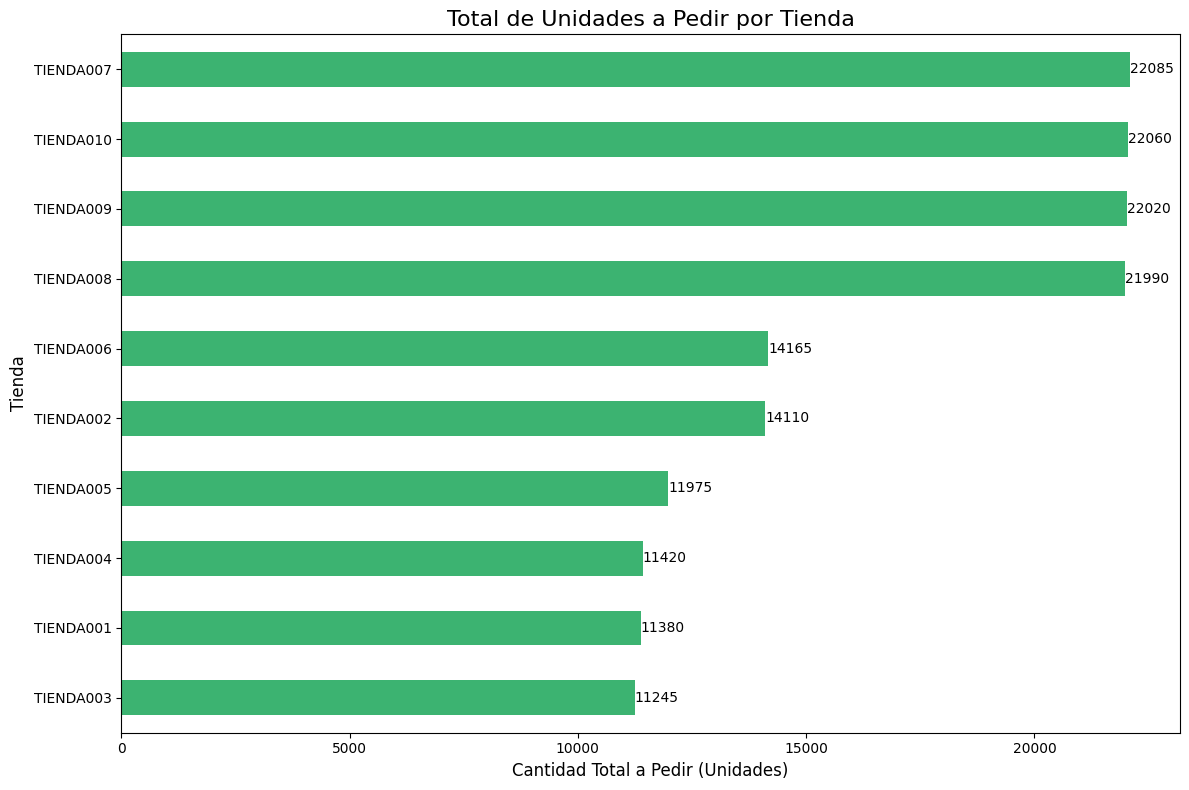

In [13]:
if not recomendaciones_compra.empty:
    # Agrupar por tienda para ver el total de unidades a pedir
    pedidos_por_tienda = recomendaciones_compra.groupby('tienda')['cantidad_a_pedir'].sum().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    pedidos_por_tienda.sort_values(ascending=True).plot(kind='barh', ax=ax, color='mediumseagreen')
    ax.set_title('Total de Unidades a Pedir por Tienda', fontsize=16)
    ax.set_xlabel('Cantidad Total a Pedir (Unidades)', fontsize=12)
    ax.set_ylabel('Tienda', fontsize=12)
    
    # Añadir etiquetas de valor
    for i, v in enumerate(pedidos_por_tienda.sort_values(ascending=True)):
        ax.text(v + 0.5, i, str(int(v)), color='black', va='center')
        
    plt.tight_layout()
    plt.show()
else:
    print("No hay recomendaciones para visualizar.")

In [14]:
import os
import pandas as pd

output_dir = 'Resultados_Optimizacion_sQ'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directorio creado: {output_dir}")

# 1. Exportar los resultados detallados para cada escenario
for nombre_escenario, df_resultado in resultados_por_escenario.items():
    nombre_archivo = os.path.join(output_dir, f"Resultados_{nombre_escenario.replace(' ', '_')}.csv")
    df_resultado.to_csv(nombre_archivo, index=False)
    print(f"Resultados para {nombre_escenario} guardados en: {nombre_archivo}")

# 2. Exportar la lista final de recomendaciones de compra
nombre_archivo_recs = os.path.join(output_dir, 'Recomendaciones_Compra_Final.csv')
recomendaciones_compra.to_csv(nombre_archivo_recs, index=False)
print(f"Recomendaciones de compra guardadas en: {nombre_archivo_recs}")

# 3. Exportar el DataFrame maestro consolidado
nombre_archivo_master = os.path.join(output_dir, 'Datos_Maestros_Consolidados.csv')
df_master.to_csv(nombre_archivo_master, index=False)
print(f"Datos maestros consolidados guardados en: {nombre_archivo_master}")

# 4. Exportar resultados combinados de todos los escenarios para Power BI (formato Montecarlo-like)
df_resultados_combinados = pd.DataFrame()
for nombre_escenario, df_resultado in resultados_por_escenario.items():
    df_temp = df_resultado.copy()
    df_temp['Escenario'] = nombre_escenario
    df_resultados_combinados = pd.concat([df_resultados_combinados, df_temp], ignore_index=True)

nombre_archivo_combinado = os.path.join(output_dir, 'Resultados_Combinados_Escenarios.csv')
df_resultados_combinados.to_csv(nombre_archivo_combinado, index=False)
print(f"Resultados combinados de escenarios para Power BI guardados en: {nombre_archivo_combinado}")


Directorio creado: Resultados_Optimizacion_sQ
Resultados para Escenario 1 guardados en: Resultados_Optimizacion_sQ\Resultados_Escenario_1.csv
Resultados para Escenario 2 guardados en: Resultados_Optimizacion_sQ\Resultados_Escenario_2.csv
Resultados para Escenario 3 guardados en: Resultados_Optimizacion_sQ\Resultados_Escenario_3.csv
Resultados para Escenario 4 guardados en: Resultados_Optimizacion_sQ\Resultados_Escenario_4.csv
Resultados para Escenario 5 guardados en: Resultados_Optimizacion_sQ\Resultados_Escenario_5.csv
Recomendaciones de compra guardadas en: Resultados_Optimizacion_sQ\Recomendaciones_Compra_Final.csv
Datos maestros consolidados guardados en: Resultados_Optimizacion_sQ\Datos_Maestros_Consolidados.csv
Resultados combinados de escenarios para Power BI guardados en: Resultados_Optimizacion_sQ\Resultados_Combinados_Escenarios.csv


## 8. Conclusión

Este notebook ha desarrollado un modelo prescriptivo completo para la optimización de inventario bajo un sistema de revisión continua (s, Q).

1.  **Análisis de Demanda:** Se procesaron los datos históricos de ventas para estimar la demanda diaria promedio y su variabilidad para cada producto y tienda.
2.  **Cálculo de Parámetros Óptimos:** Se implementó un optimizador que calcula la cantidad de pedido (`Q_optimo`) y el punto de reorden (`punto_reorden`) basándose en las fórmulas de EOQ y stock de seguridad.
3.  **Análisis de Escenarios:** El modelo se aplicó a múltiples escenarios de costos, demostrando cómo los parámetros óptimos cambian en función de los costos de operación.
4.  **Recomendaciones Prescriptivas:** Se generó una lista de órdenes de compra clara y accionable para el 'Escenario 1', que sirve como una guía directa para el equipo de compras.

El resultado es un sistema que no solo describe el estado actual del inventario, sino que **prescribe acciones concretas** para minimizar costos y mantener un nivel de servicio adecuado. Este modelo puede ser fácilmente ajustado para re-evaluar las políticas de inventario si los costos logísticos o los patrones de demanda cambian en el futuro.